# 1. CAREFLの単純な生成性能評価：尤度を用いた比較

## 1.1 合成データの真の結合確率分布の計算モジュール実装

In [3]:
import numpy as np
import igraph as ig
from typing import Callable, Optional, Union, Tuple




def _normal_logpdf(x: np.ndarray, mu: np.ndarray, sigma: Union[float, np.ndarray]) -> np.ndarray:
    """要素ごとの log N(x | mu, sigma^2)。x, mu, sigma はブロードキャスト可能。"""
    sigma = np.asarray(sigma)
    var = sigma ** 2
    return -0.5 * (np.log(2.0 * np.pi * var) + ((x - mu) ** 2) / var)

def build_sem_logpdf(
    W: np.ndarray,
    gamma: Optional[np.ndarray],
    sem_type: str = "linear",
    noise_scale: Union[float, np.ndarray] = 1.0,
) -> Tuple[Callable[[np.ndarray], np.ndarray], Callable[[np.ndarray], np.ndarray]]:
    """
    SEMの設定（W, gamma, sem_type, noise_scale）から、
    データ X (shape = [n_samples, d]) を入れると **結合対数尤度**を返す関数 logpdf_fn と
    **尤度値**を返す関数 pdf_fn を生成して返す。

    前提:
      - 加法的ガウスノイズ:  x_i = f_i(x_pa(i)) + ε_i,  ε_i ~ N(0, σ_i^2)
      - sem_type は 'linear' または 'tanh' を想定（必要なら拡張可能）

    Args:
        W: [d, d] 重み付き隣接行列（DAG）
        gamma: [d] 非線形強度（linear の場合は None も可。内部で ones に置換）
        sem_type: 'linear' | 'tanh'
        noise_scale: ノイズ標準偏差（スカラー or 長さ d）

    Returns:
        logpdf_fn(X): [n] 各サンプルの結合対数尤度（log p(X)）
        pdf_fn(X):    [n] 各サンプルの結合尤度（p(X)）※オーバーフロー回避のため小規模データ向け
    """
    W = np.asarray(W)
    d = W.shape[0]

    # ノイズ標準偏差ベクトル
    if np.isscalar(noise_scale):
        sigma = float(noise_scale) * np.ones(d)
    else:
        sigma = np.asarray(noise_scale, dtype=float)
        if sigma.shape != (d,):
            raise ValueError("noise_scale must be a scalar or length-d vector.")

    # gamma ベクトル
    if gamma is None:
        gamma_vec = np.ones(d, dtype=float)
    else:
        gamma_vec = np.asarray(gamma, dtype=float)
        if gamma_vec.shape != (d,):
            raise ValueError("gamma must be length-d vector or None.")

    # トポ順と親集合を事前計算（DAGチェックは igraph のトポソート失敗で検出される想定）
    G = ig.Graph.Weighted_Adjacency(W.tolist())
    order = G.topological_sorting()
    if len(order) != d:
        raise ValueError("W must define a DAG (topological_sorting failed).")
    parents_list = [G.neighbors(j, mode=ig.IN) for j in range(d)]

    # 条件平均 μ_j(x_pa(j)) を計算する内部関数
    def _cond_mean(X: np.ndarray, j: int) -> np.ndarray:
        pa = parents_list[j]
        if len(pa) == 0:
            z = 0.0
        else:
            z = X[:, pa] @ W[pa, j]
        if sem_type == "linear":
            return z
        elif sem_type == "tanh":
            return gamma_vec[j] * np.tanh(z)
        else:
            raise ValueError(f"Unsupported sem_type: {sem_type}")

    # log p(X) = sum_i log p(x_i | x_pa(i)) を返す
    def logpdf_fn(X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or X.shape[1] != d:
            raise ValueError(f"X must have shape [n, {d}]")
        n = X.shape[0]
        logp = np.zeros(n, dtype=float)
        # 因果的マルコフ条件で因子化：製品→和（log）に
        for j in order:
            mu_j = _cond_mean(X, j)
            logp += _normal_logpdf(X[:, j], mu_j, sigma[j])
        return logp

    # 数値的には log のまま扱うのが安全。必要な場合のみ exp に変換
    def pdf_fn(X: np.ndarray) -> np.ndarray:
        return np.exp(logpdf_fn(X))

    return logpdf_fn, pdf_fn


### 因果モデルの結合対数尤度計算モジュールの動作確認

In [3]:
import os

os.chdir('/home/hashikami/projects/Diff')

#### 線形ケースでの確認

In [10]:
from notears.utils import simulate_dag, simulate_parameter, simulate_linear_sem
import numpy as np


# 線形SEMデータの生成
n, d, s0, graph_type, sem_type = 1024, 20, 20, 'ER', 'gauss'
B_true = simulate_dag(d, s0, graph_type)
W = simulate_parameter(B_true)
X = simulate_linear_sem(W, n, sem_type)

# 比較対象：単純なノイズ
X_rand = np.random.normal(0, 1, (n, d))


In [17]:
# 例: 線形SEM（σ=1）
logpdf_fn, pdf_fn = build_sem_logpdf(W, gamma=None, sem_type="linear", noise_scale=1.0)
ll = logpdf_fn(X) 
nll = -ll.mean() / d
print(nll)

ll_rand = logpdf_fn(X_rand)
nll_rand = -ll_rand.mean() / d
print(nll_rand)


1.4265679158259723
2.0876822712200496


In [13]:
# CareFlでの生成性能評価

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from torch.distributions import MultivariateNormal
import igraph as ig
from tqdm.auto import tqdm
from carefl.nflib.flows import DAGAffineCL, NormalizingFlowModel
from carefl.models.carefl import CAREFL
from carefl.data.generate_synth_data import CustomSyntheticDataset
from carefl.nflib.nets import MLP4




device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


dset = CustomSyntheticDataset(X.astype(np.float32), device)
train_loader = DataLoader(dset, shuffle=True, batch_size=128)

prior = MultivariateNormal(torch.zeros(d).to(device), torch.eye(d).to(device))
G = ig.Graph.Adjacency(B_true.tolist(), mode='directed')
ordered_vertices = G.topological_sorting()
flow_list = []

for v in ordered_vertices[::-1]:
    cond_idx = G.neighbors(v, mode=ig.IN)
    affine = DAGAffineCL(d, cond_idx, [v], MLP4, 100, False, True)
    flow_list.append(affine)

flow = NormalizingFlowModel(prior, flow_list).to(device)
flow.train()
optimizer = optim.Adam(flow.parameters(), lr=1e-3)

epochs = 200
for e in tqdm(range(epochs)):
    loss_val = 0.0
    for _, x in enumerate(train_loader):
        x = x.to(device)
        _, prior_logprob, log_det = flow(x)
        loss = - torch.sum(prior_logprob + log_det)
        loss_val += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [01:24<00:00,  2.36it/s]


In [18]:
X_gen = flow.sample(1000)[-1].detach().cpu().numpy()
ll_gen = logpdf_fn(X_gen)
nll_gen = -ll_gen.mean() / d
print(nll_gen)


1.4144820278984946


## 1.2 評価実験1: 様々な実験設定での真モデルとCareFLの尤度比較

### 1.2.1 様々な実験設定で学習しその際の設定と尤度値を保存

In [7]:
import torch
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from torch.distributions import MultivariateNormal
import igraph as ig
from tqdm.auto import tqdm
from carefl.nflib.flows import DAGAffineCL, NormalizingFlowModel
from carefl.data.generate_synth_data import CustomSyntheticDataset
from carefl.nflib.nets import MLP4
from notears.utils import simulate_linear_sem, simulate_nonlinear_sem
from notears.linear import notears_linear


n = 1024
gamma_scale = 3.0
epochs = 200


def train_carefl(X, B):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    d = X.shape[1]

    dset = CustomSyntheticDataset(X.astype(np.float32), device)
    train_loader = DataLoader(dset, shuffle=True, batch_size=128)

    prior = MultivariateNormal(torch.zeros(d).to(device), torch.eye(d).to(device))
    G = ig.Graph.Adjacency(B.tolist(), mode='directed')
    ordered_vertices = G.topological_sorting()
    flow_list = []

    for v in ordered_vertices[::-1]:
        cond_idx = G.neighbors(v, mode=ig.IN)
        affine = DAGAffineCL(d, cond_idx, [v], MLP4, 100, False, True)
        flow_list.append(affine)

    flow = NormalizingFlowModel(prior, flow_list).to(device)
    flow.train()
    optimizer = optim.Adam(flow.parameters(), lr=1e-3)

    for e in tqdm(range(epochs)):
        loss_val = 0.0
        for _, x in enumerate(train_loader):
            x = x.to(device)
            _, prior_logprob, log_det = flow(x)
            loss = - torch.sum(prior_logprob + log_det)
            loss_val += loss.item()
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
    return flow
    


def bpd_score_with_various_cases(W_true, use_notears, case, model):
    
    # シミュレーションデータの生成と真モデルの尤度値の計算
    d = W_true.shape[0]
    if case == 'linear':
        X = simulate_linear_sem(W_true, n, sem_type='gauss')
        logpdf_fn, _ = build_sem_logpdf(W_true, gamma=None, sem_type="linear", noise_scale=1.0)
        if model == 'true model':
            ll = logpdf_fn(X) 
            nll = -ll.mean() / d # shape=(n,)
            return nll
        
    elif case == 'tanh':
        gamma = gamma_scale * np.ones(d)
        X = simulate_nonlinear_sem(W_true, gamma, n, sem_type='tanh')
        logpdf_fn, _ = build_sem_logpdf(W_true, gamma=gamma, sem_type="tanh", noise_scale=1.0)
        if model == 'true model':
            ll = logpdf_fn(X) 
            nll = -ll.mean() / d # shape=(n,)
            return nll
    
    # (因果探索ありの場合)NOTEARSで因果構造を推定
    if use_notears:
        W_est = notears_linear(X, 0.1, loss_type='l2', w_threshold=0.3)
        B = W_est != 0
    else:
        B = W_true != 0
        
    # 真の(または推定された)因果構造に従ってCAREFLを学習
    flow = train_carefl(X, B)
    X_gen = flow.sample(n)[-1].detach().cpu().numpy()
    ll_gen = logpdf_fn(X_gen) 
    nll_gen = -ll_gen.mean() / d # shape=(n,)
    
    return nll_gen

In [8]:
from notears.utils import simulate_dag, simulate_parameter
import pandas as pd
import numpy as np


graph_type = 'ER'
s0_scale = 2
gamma_scale = 3.0

results = []
for d in [10, 20, 50, 100]:
    for use_notears in [True, False]:
        for case in ['linear', 'tanh']:
            for model in ['true model', 'carefl']:
                s0 = s0_scale * d
                B_true = simulate_dag(d, s0, graph_type)
                W_true = simulate_parameter(B_true)
                nll = bpd_score_with_various_cases(W_true, use_notears, case, model)
            
                results.append({
                    "n_nodes": d,
                    "use_notears": use_notears,
                    "case": case,
                    "model": model,
                    "neg_log_likelihood": nll,
                })
            
df = pd.DataFrame(results)
            

100%|██████████| 200/200 [03:20<00:00,  1.00s/it]


KeyboardInterrupt: 

### 1.2.2 実験結果の可視化

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_likelihood_grid(
    csv_path: str,
    savepath: str = None,
    nodes_list=(10, 20, 50, 100),
    case_order=("linear", "tanh"),
    use_notears_order=(True, False),
    model_order=("carefl", "true model"),
    model_colors=None,
    figsize=(10, 6),
    title="Negative log-likelihood per dim (↓ better)"
):
    """
    csv_path: 実験結果CSVのパス（カラム：
        n_nodes, use_notears, case, model, neg_log_likelihood_per_dim）
    """

    df = pd.read_csv(csv_path)
    # 型をきちんとそろえる
    df["n_nodes"] = df["n_nodes"].astype(int)
    # True/False が文字列になっている可能性に対応
    if df["use_notears"].dtype == object:
        df["use_notears"] = df["use_notears"].map(
            lambda x: True if str(x).lower() in {"true", "1"} else False
        )
    df["case"] = df["case"].astype(str)
    df["model"] = df["model"].astype(str)

    if model_colors is None:
        model_colors = {"carefl": "tab:red", "true model": "tab:green"}

    # 共通Y範囲を先に決める
    y = df["neg_log_likelihood_per_dim"].astype(float).values
    y_min, y_max = np.nanmin(y), np.nanmax(y)
    pad = 0.05 * (y_max - y_min if y_max > y_min else 1.0)
    #y_lim = (y_min - pad, y_max + pad)
    y_lim = (y_min - 0.1, 2.0)
    

    fig, axes = plt.subplots(
        nrows=len(use_notears_order),
        ncols=len(case_order),
        figsize=figsize,
        sharey=True,
    )

    if len(use_notears_order) == 1 and len(case_order) == 1:
        axes = np.array([[axes]])
    elif len(use_notears_order) == 1:
        axes = np.array([axes])

    for r, use_nt in enumerate(use_notears_order):
        for c, case in enumerate(case_order):
            ax = axes[r, c]
            sub = df[(df["use_notears"] == use_nt) & (df["case"] == case)]

            # ノード数の順に並び替え
            sub = sub[sub["n_nodes"].isin(nodes_list)]
            # モデルごとにラインを描画
            for mdl in model_order:
                sub_m = sub[sub["model"] == mdl].copy()
                if sub_m.empty:
                    continue
                # 指定ノード順で並べ替え（欠損は落とす）
                sub_m = sub_m.set_index("n_nodes").reindex(nodes_list).dropna(subset=["neg_log_likelihood_per_dim"]).reset_index()
                if not sub_m.empty:
                    ax.plot(
                        sub_m["n_nodes"].values,
                        sub_m["neg_log_likelihood_per_dim"].values.astype(float),
                        marker="o",
                        linewidth=2,
                        label=mdl,
                        color=model_colors.get(mdl, None),
                    )

            ax.set_ylim(*y_lim)
            ax.set_xticks(list(nodes_list))
            ax.set_xlabel("Number of nodes")
            if c == 0:
                ax.set_ylabel("Neg. log-likelihood / dim")
            ax.grid(True, linestyle="--", alpha=0.3)

            # 小タイトル（列=case）
            if r == 0:
                ax.set_title(f"case = {case}")
            # 行ラベル（因果探索の有無）
            ax.text(
                0.02, 0.95,
                f"use_notears = {use_nt}",
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.7),
            )

    # 共通凡例（下中央）
    handles, labels = axes[-1, -1].get_legend_handles_labels()
    if not handles:
        # どこかの軸から取得
        for row in axes:
            for ax in row:
                h, l = ax.get_legend_handles_labels()
                if h:
                    handles, labels = h, l
                    break
            if handles:
                break
    if handles:
        fig.legend(handles, labels, loc="lower center", ncol=len(model_order), bbox_to_anchor=(0.5, -0.03))

    fig.suptitle(title, y=1.02, fontsize=13)
    fig.tight_layout()

    if savepath:
        Path(savepath).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, bbox_inches="tight", dpi=200)

    return fig, axes

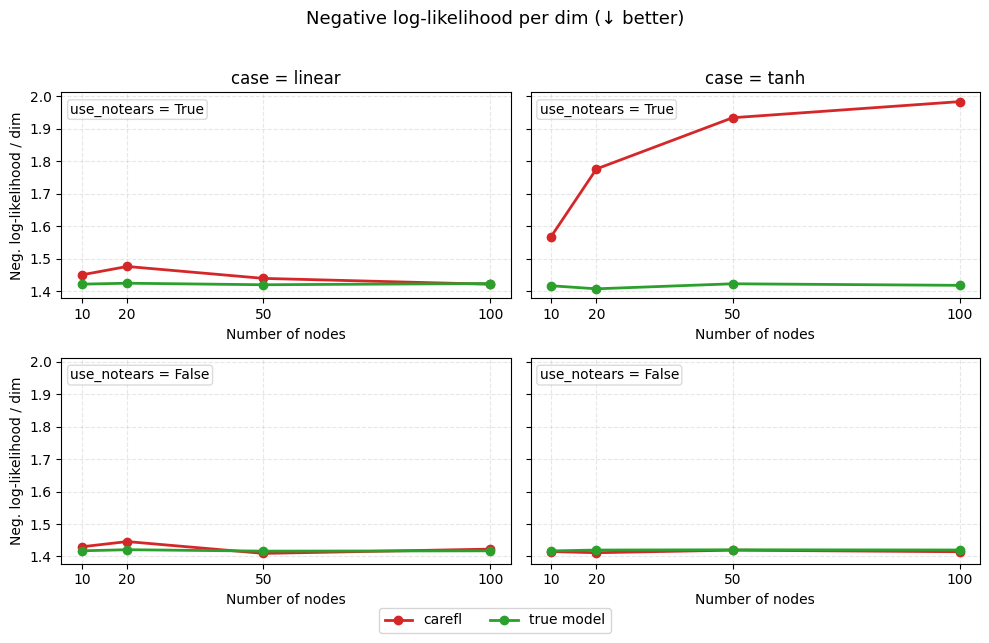

In [5]:
fig, axes = plot_likelihood_grid(
    csv_path="results/carefl_evaluate/carefl_eval_n1024_gamma3.0_s02.0_20250828-193006.csv",
    savepath=None,
    nodes_list=(10,20,50,100),
    case_order=("linear","tanh"),
    use_notears_order=(True, False),
    model_order=("carefl","true model"),
)
plt.show()

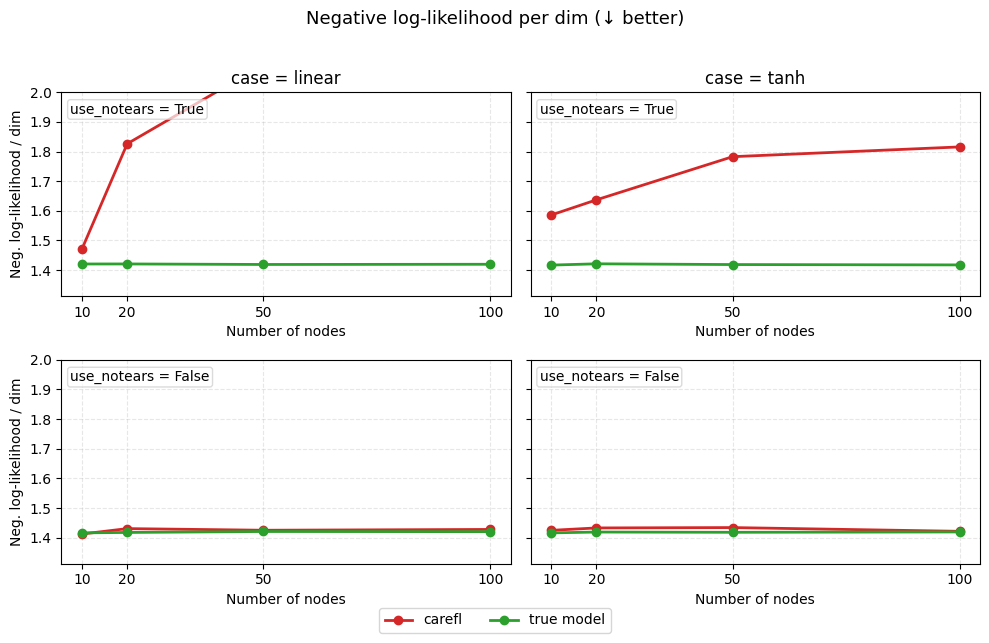

In [23]:
fig, axes = plot_likelihood_grid(
    csv_path="results//carefl_evaluate/carefl_eval_n4096_gamma3.0_s02.0_20250910-222617.csv",
    savepath=None,
    nodes_list=(10,20,50,100),
    case_order=("linear","tanh"),
    use_notears_order=(True, False),
    model_order=("carefl","true model"),
)
plt.show()

### linear かつ 因果探索ありケースの解析

In [27]:
import pandas as pd


df = pd.read_csv("results/carefl_evaluate/carefl_eval_n4096_gamma3.0_s02.0_20250910-222617.csv")
df_linear_use_notears = df[(df["case"] == "linear") & (df["use_notears"] == True)]
df_linear_use_notears.head(10)

,n_nodes,use_notears,case,model,neg_log_likelihood_per_dim
0,10,True,linear,true model,1.420431e+00
1,10,True,linear,carefl,1.469939e+00
8,20,True,linear,true model,1.420569e+00
9,20,True,linear,carefl,1.826185e+00
16,50,True,linear,true model,1.418788e+00
17,50,True,linear,carefl,2.093336e+00
24,100,True,linear,true model,1.419462e+00
25,100,True,linear,carefl,4.264020e+06


In [32]:
import numpy as np

W_est = np.random.randn(10, 10)
B_est_1 = (W_est != 0)
B_est_2 = W_est != 0

print(B_est_1)
print(B_est_2)


[[ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  Tru

In [31]:
B_est_3 = (W_est != 0).astype(np.int32)
print(B_est_3)

[[1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]]
